# Pipeline for processing CZI files and segmentation.

In [1]:

import copy

import numpy as np
from aicspylibczi import CziFile
from pathlib import Path

import xml.etree.ElementTree as ET
import xml.dom.minidom

import cv2
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from PIL import Image
from skimage import filters, segmentation, morphology, color, exposure, restoration, measure, feature
from skimage.measure import regionprops_table
from skimage.filters import threshold_otsu, threshold_triangle, threshold_local

from sklearn import preprocessing as p
from skimage.segmentation import find_boundaries
from skimage.measure import regionprops, label


from stardist.models import StarDist2D
from csbdeep.utils import normalize

from scipy import ndimage
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import tifffile

2025-06-07 00:38:38.985316: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-07 00:38:39.341843: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-07 00:38:39.641974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749271119.907300  818741 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749271119.979636  818741 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-07 00:38:40.702190: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

from skimage import io
from btrack import datasets
import btrack
import tifffile
import napari


#### 2024-12-21-PRRX1-MYOD-3-01.czi
- This is 0-24 hours (according to the timeline below)
- 68 time points, 20 min intervals
- Note that the 68th time point is messed up and should be removed
- Size: 113.2 GB

#### 2024-12-22-PRRX1-MYOD-3-02.czi
This is 24-72 hours (according to the timeline below)
137 time points, 20 min intervals
Size: 231.5 GB

#### Scenes:
These czi's both contain 18 scenes, some with and without the nuclear stain (SiR-DNA). For analysis, we are only interested in the scenes with SiR-DNA. Those scenes (and their respective conditions) are described here:
- Cells only (negative control): s1, s7, s13
- PRRX1 only: s2, s3
- MYOD1 only: s14, s15
- PRRX1+MYOD1: s8, s9, s11

#### Channel order:
- TagGFP (Green)
- mKate (Red)
- Cy5 (Nuclear stain)
- Oblique

In [3]:
# defining Base Path where all intermediate files will be written
basepath = '/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tempdata'

image_path = basepath + '/original_images'
if not os.path.exists(image_path):
    os.makedirs(image_path)

image_path = basepath + '/segmentation_masks'
if not os.path.exists(image_path):
    os.makedirs(image_path)

image_path = basepath + '/binary_masks/'
if not os.path.exists(image_path):
    os.makedirs(image_path)

    

In [7]:
# Helpers
def norm_by(x, min_, max_):
    """
    normalization function, taking in a percentile range to clip
    
    :param x: 2d numpy array to be normalized
    :type x: 2d numpy array
    
    :param min_: Minimum percentile to clip out
    :type min_: int (0-100)
    
    :param max_: Maximum percentile to clip out
    :type max_: int (0-100)
    
    :return: 3 channel cmy image
    :rtype: 3 mode numpy array
    """
    norms = np.percentile(x, [min_, max_])
    i2 = np.clip((x - norms[0]) / (norms[1] - norms[0]), 0, 1)
    return i2


def recolor(im):
    """
    given an rgb image, convert to cyan-magenta-yellow
    :param im: 3 channel image
    :type im: 3 mode numpy array
    
    :return: 3 channel cmy image
    :rtype: 3 mode numpy array
    """
    im_shape = np.array(im.shape)
    color_transform = np.array([[1, 1, 0], [0, 1, 1], [1, 0, 1]]).T
    im_reshape = im.reshape([np.prod(im_shape[0:2]), im_shape[2]]).T
    im_recolored = np.matmul(color_transform.T, im_reshape).T
    im_shape[2] = 3
    im = im_recolored.reshape(im_shape)
    return im

def merge_channels(channel1, channel2, weights=(0.5, 0.5)):
    """
    Given 2 2d arrays, merge them with a certain weight factor
    
    :param channel1: first channel to be merged
    :type channel1: 2d numpy array

    :param channel2: first channel to be merged
    :type channel2: 2d numpy array

    :param channel1: percentage to merge the channels
    :type channel1: set of ints
    
    :return: merged channel based on the weights
    :rtype: 2d numpy array
    """
    if channel1.shape != channel2.shape:
        raise ValueError("Channels must have the same dimensions.")

    if len(weights) != 2:
         raise ValueError("Weights must be a tuple of length 2.")

    merged_channel = (weights[0] * channel1) + (weights[1] * channel2)
    return merged_channel
    
def plot_mosaic(c1, c2, c3, plot=True):
    """
    Helper to normalize raw channels from mosaic tiles and optionally plot them
    
    :param c1, c2, c3: channel arrays
    :type c1, c2, c3: 2d numpy array

    :param plot: Optional flag to plot the image
    :type plot: bool
    
    :return: Returns all the normalized channels
    :rtype: set(numpy.array)
    """
    scalex = 471
    scaley = 649

    timex = (scalex) * 2
    timey = (scaley) * 2
    c1 = (norm_by(c1[0, 0, 0, 0:timex, 0:timey], 50, 99.8) * 255).astype(np.uint8)
    c2 = (norm_by(c2[0, 0, 0, 0:timex, 0:timey], 50, 99.8) * 255).astype(np.uint8)
    c3 = (norm_by(c3[0, 0, 0, 0:timex, 0:timey], 50, 99.8) * 255).astype(np.uint8)
    c5 = merge_channels(c1, c2)

    # stacked full color image
    rgb = np.stack((c1, c2, c3), axis=2)

    # Channel wise plot
    if plot:
        
        fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 10))
        axes[0].imshow(c1)
        axes[1].imshow(c2)
        axes[2].imshow(c3)
        axes[3].imshow(c5)
    
        axes[0].set_title('Channel 1')
        axes[1].set_title('Channel 2')
        axes[2].set_title('Channel 3')
        axes[3].set_title('Channel 5')
    
    return (c1, c2, c3, c5, rgb)

def remove_background_noise(channel, noisemap, strength=1):

    print(f"Channel Min: {np.min(channel)}, Channel Max: {np.max(channel)}")

    print(f"Noise Min: {np.min(noisemap)}, Noise Max: {np.max(noisemap)}")
    H, W = channel.shape
    h, w = noisemap.shape

    output = np.copy(channel)

    # Dual loops with edge limits for noise removal
    for i in range(0, H, h):
        for j in range(0, W, w):
            i_end = min(i + h, H)
            j_end = min(j + w, W)
            
            image_patch = channel[i:i_end, j:j_end].astype(np.float32)
            tile_patch = noisemap[:i_end - i, :j_end - j].astype(np.float32)
    
            result_patch = np.clip(image_patch - tile_patch * strength, 0, 255)

            output[i:i_end, j:j_end] = result_patch
    # plt.figure()
    # plt.imshow(noisemap)
    # plt.colorbar()
    # plt.figure()
    # plt.imshow(channel)
    # plt.colorbar()
    # plt.title('original')
    # plt.figure()
    # plt.imshow(output)
    # plt.colorbar()
    # plt.title('Noise Removed')
    
def plot_image(img, noisemap=None, plot=False):
    """
    Helper to normalize raw channels and optionally plot them
    
    :param img: the image to be plotted as a numpy array
    :type img: 3 mode numpy array

    :param plot: Optional flag to plot the image
    :type plot: bool
    
    :return: merged channel based on the weights
    :rtype: set(numpy.array)
    order of return
    taggfp, mkate, cy5, oblique, taggfp_mkate, cur_rgb
    """
    taggfp = img[ 0, ::, ::]
    mkate = img[ 1, ::, ::]
    cy5 = img[ 2, ::, ::]

    taggfp = (norm_by(taggfp, 50, 99.8) * 255).astype(np.uint8)
    mkate = (norm_by(mkate, 50, 99.8) * 255).astype(np.uint8)
    cy5 = (norm_by(cy5, 50, 99.8) * 255).astype(np.uint8)
    if noisemap:    
        remove_background_noise(taggfp, noisemap['TaGGFP'], strength=1)
        remove_background_noise(mkate, noisemap['mKate'], strength=1)
        # We are intentionally using the same noisemap as taggfp
        remove_background_noise(cy5, noisemap['TaGGFP'], strength=1)

    
    c1 = taggfp
    c2 = mkate
    c3 = cy5
    c4 = (norm_by(img[ 3, ::, ::], 0, 100) * 255).astype(np.uint8)
    c5 = merge_channels(c1, c2)
    
    rgb = np.stack((c1, c2, c3), axis=2)

    # Channel wise plot
    if plot:
        
        fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 10))
        axes[0].imshow(c1)
        axes[1].imshow(c2)
        axes[2].imshow(c3)
        axes[3].imshow(c4)
        axes[4].imshow(c5)
    
        axes[0].set_title('Channel 1')
        axes[1].set_title('Channel 2')
        axes[2].set_title('Channel 3')
        axes[3].set_title('Channel 4')
        axes[4].set_title('Channel 5')
    
    return (c1, c2, c3, c4, c5, rgb)

def convert_to_rgb(values, col):
    zeroes = np.zeros_like(values, dtype=float)
    if col.lower() == 'r':
        conv = np.array([values, zeroes, zeroes], dtype=float)
    elif col.lower() =='g':
        conv = np.array([zeroes, values, zeroes], dtype=float)
    elif col.lower() =='b':
        conv = np.array([zeroes, zeroes, values], dtype=float)
    return

In [5]:
### Mostly for mosaic images.

class Cell():
    def __init__(self, centre):
        pass

    def track_over_time():
        pass

class Frame():
    """
    Class representing a single frame from the timelapse video

    :param image: actual image frame as a 3 mode numpy array
    :type image: 3d numpy array

    :param frame_num: order of the frame in the entire movie
    :type frame_num: int
    
    :param plot: Optionally plot the image.
    :type plot: bool
    
    :param save: save mask labels as tiff files
    :type save: bool

    Methods:
    :function channel_runner: performs channel specefic tasks eg. counting cells
    :function get_channel_counts: gets the count of cells in a specific channel
    :function segmenter: core image processing function runs basic workflow on the image and generates data for furnther tasks
    :function get_properties: Fetches the basic properties from the mask label
    :function fetch_centroids: fetches centroids for the frame
    :function fetch_labels: fetches labels from the properties dictionary 
    :function track_next_frame: Tracks cells across two given frames
    """
    def __init__(self, image, frame_num, plot=False, save=False):
        self.image = image
        self.plot = plot
        self.save = save
        self.taggfp, self.mkate, self.cy5, self.oblique, self.taggfp_mkate, self.full_rg = image
        self.active_channel = self.taggfp_mkate
        self.threshold = 1e5
        self.max_distance=50
        self.og_frame = frame_num
        self.frame_num = frame_num
        self.cells = []
        _, self.mask_labels, self.binary_labels = self.segmenter(self.active_channel)
        self.properties = regionprops_table(
            self.mask_labels, 
            properties=('label', 'centroid', 'area', 'bbox')
        ) 
        self.props = measure.regionprops(self.binary_labels)
        self.ycenters, self.xcenters, self.centroids = self.fetch_centroids(self.properties)
        self.cell_count = label(self.binary_labels).max()
        
        self.labels = self.fetch_labels()
        
    def channel_runner(self):
        """
        Helper that takes all channels and runs specified functions on them.

        :return: returns metrics for each channel
        :rtype: set of channel metrics
        """
        self.save = True
        self.plot = False
        self.frame_num = str(self.og_frame) + '_taggfp'
        taggfp_count = self.get_channel_counts(self.taggfp)
        
        self.frame_num = str(self.og_frame) + '_mkate'
        mkate_count = self.get_channel_counts(self.mkate)
        
        self.frame_num = str(self.og_frame) + '_cy5'
        cy5_count = self.get_channel_counts(self.cy5)
        
        self.frame_num = str(self.og_frame) + '_total'
        tag_mkate_count = self.get_channel_counts(self.taggfp_mkate)
        
        return taggfp_count, mkate_count, cy5_count, tag_mkate_count

    def get_channel_counts(self, channel):
        """
        Counts number of cells in the channel
        
        :param channel: channel to be processed
        :type channel: 2d array
         
        :return: count of cells in the array
        :rtype: int
        """
        _, mask_labels, binary_labels = self.segmenter(channel)
        properties = regionprops_table(
            mask_labels, 
            properties=('label', 'centroid', 'area', 'bbox')
        ) 
        props = measure.regionprops(binary_labels)
        ycenters, xcenters, centroids = self.fetch_centroids(properties)
        # self.cell_count = len(self.properties['area'])
        cell_count = label(binary_labels).max()
        return cell_count
    
    
    def segmenter(self, channel):
        """
        Core segmentation processor. Runs image processing filters and thresholding to separate out cells as foreground and the noise as background

        :param channel: the channel as a 2d array
        :type channel: numpy 2d array

        :return: (processed image, raw labels, and thresholded binary labels)
        :rtype: set(numupy.2darray)
        """
        # Segnemnts channels into separate cells.
            
    
        min_max_scaler = p.Normalizer()
        normalizedData = min_max_scaler.fit_transform(channel)
        
        processed = normalizedData
        blurred = filters.gaussian(processed, sigma=2)
    
        thresh = blurred > filters.threshold_otsu(blurred)
    
        cleaned = morphology.remove_small_objects(thresh, min_size=50)
        
        
        
        distance = ndimage.distance_transform_edt(cleaned)
        coords = feature.peak_local_max(distance, labels=cleaned)
        mask = np.zeros(distance.shape, dtype=bool)
        mask[tuple(coords.T)] = True
        markers = measure.label(mask)
        labels = segmentation.watershed(-distance, markers, mask=cleaned)
        
        segmented_overlay = color.label2rgb(
            labels, 
            image=channel, 
            bg_label=0,
            alpha=0.3,
            colors=['cyan', 'yellow', 'magenta']  # Custom colors for labels
        )

        boundaries = find_boundaries(labels, mode='inner')
        labelcp = copy.deepcopy(labels)

        labels[labels > 1] = 1

        # #Blue
        # cmap = ListedColormap(['none', '#4529ff'])
        # Bright grey
        cmap = ListedColormap(['none', '#deffef'])

        if self.plot:
            print('plotting')
            fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 10))
            
            for i in axes:
                i.axis('off')
            axes[0].imshow(channel)
            axes[0].set_title('Channel')
            
            axes[1].imshow(processed)
            axes[1].set_title('Normalized Channel')
            
            axes[2].imshow(labelcp, cmap='nipy_spectral')
            axes[2].set_title('Better colored Labels')
            
            axes[3].imshow(channel, cmap='grey')
            axes[3].imshow(labels, cmap=cmap, alpha=0.7)
            axes[3].set_title('Overlay of segments')

            if self.save:
                axes[3].figure.savefig(f"figures/Frame_segmentation_{self.frame_num}.png")
        return processed, labelcp, labels

    def get_properties(self):
        """
        Fetch segmentation properties such as 'label', 'centroid-0', 'centroid-1', 'area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3'
        """
        return self.properties
    
    def fetch_centroids(self, props):
        """
        fetch segmentation centroids
        """
        centroid_rows = props['centroid-0']
        centroid_columns = props['centroid-1']
        return centroid_rows, centroid_columns, np.array(list(zip(centroid_rows, centroid_columns)))

    def fetch_labels(self):
        """
        Fetch segmentation labels from the properties object
        """
        labels = self.properties['label']
        return labels
        
    def track_next_frame(self, next_frame):
        """
        Use Btrack to track the next frame segments
        """
        objects = btrack.utils.segmentation_to_objects(
                      seg, properties=('area', )
                    )


# Loading Dataset

### Loading from Kaggle dataset

In [117]:
class HybridReprogramming():
    """
    Dataloader class for interacting with the published dataset

    :param sample: The sample of the experiment you want to load
    :type sample: str
    
    :param sampleID: The sample Id within the experimental sample
    :type sampleID: int

    
    :param basepath: The Basepath where the dataset is loaded from kaggle
    :type basepath: path
    
    """
    def __init__(self, sample, sampleID, basepath):
        self.sample = sample
        self.sampleID = sampleID
        self.channels = 3
        self.basepath = basepath

    def load_Genexpression(self):
        """
        Load the genexpression dataset into an anndata object

        :return: The fully loaded anndata object to be used with scanpy
        :rtype: anndata
        """
        filepath = f'{self.basepath}/GeneExpression/Genexpression.h5ad'
        anndata = sc.read_h5ad(filepath)
        return anndata

    def load_frames(self, time_start, time_end):
        """
        Method to load the imaging data

        :param time_start: The starting timepoint where the data should be loaded for
        :type time_start: int

        :param time_start: The end timepoint for the data to be loaded
        :type time_start: int
        
        :return: returns the frames as a stack for the given time start and end ranges
        :rtype: np.array()
        """
        frames = []
        for t in range(time_start, time_end):
            filepath = f'{self.basepath}/Imaging/Imaging/{self.sample}/{self.sampleID}/t_{t+1}.hdf5'
            f = h5py.File(filepath, 'r')
            frame_shape = f['Scene'].shape
            frame = f['Scene'][:]
            frames.append(frame)
        framestack = np.stack(frames, axis=0)
        return framestack

def masks_to_btrack_objects(exp):
    """
    Converts the generated masks into btrack objects. 

    :param exp: The experiment object that loads in the required data
    :type exp: HybridReprogramming

    :return: The btrack objects
    :rtype: list(btrack objects)
    
    """
    objects = []
    for t, frame in enumerate(exp.frame_list):
        fig, ax = plt.subplots(figsize=(10, 10))
        # ax.imshow(frame.binary_labels)
        mask = frame.mask_labels
        props = regionprops(mask)
        for obj in props:
            y, x = obj.centroid 
            objects.append({
                'ID': obj.label,  
                't': t,           
                'x': x,            
                'y': y,             
                'z': 0,             
                'prob': 1.0,       
                'states': 0,
                'area': obj.area,
            })
    return objects

def tracks_to_csv(tracks):
    """
    Converts the btrack tracks to csv files that can be exported or loaded elsewhere
    :param tracks: Btrack tracks to be converted
    :type tracks: Btrak.track

    :return: None, creates a csv file with the track data
    """
    df = pd.DataFrame([{
        'track_id': track.ID,
        't': track.t,
        'x': track.x,
        'y': track.y,
        'parent': track.parent,
        'root': track.root,
    } for track in tracks])
    
    # Save to CSV
    df.to_csv('cell_tracks.csv', index=False)

def count_and_save_image(basepath, sample, sampleid, t, frame):
    np.save(f"{basepath}/binary_masks/{sample}_{sampleid}_mask_t{t}.npy" ,frame.binary_labels)
    counters = frame.channel_runner()
    # Save original images

    # Masks
    img = frame.active_channel
    mask = frame.binary_labels
    
    # fig, ax = plt.subplots(figsize=(10, 10))
    # ax.imshow(mask)
    
    tifffile.imwrite(
        f'{basepath}/original_images/frame_{t:03d}.tif',
        img.astype(np.uint16),  # Use uint16 for microscopy data
        metadata={'axes': 'YX'},  # Add metadata for clarity
    )

    tifffile.imwrite(
        f'{basepath}/segmentation_masks/mask_{t:03d}.tif',
        mask.astype(np.uint16),
        metadata={'axes': 'YX', 'mode': 'labels'},  # Optional metadata
    )
    return counters

def run_experiment(path, sample, sampleid, noisemap, t1=1, t2=10, save_counts=False):
    """
    Helper function that loads in the experiment and runs segmentation, tracking and saves outputs to specified locations

    :param sample: The sample of the experiment you want to load
    :type sample: str
    
    :param sampleID: The sample Id within the experimental sample
    :type sampleID: int

    :param t1: The starting timepoint where the data should be loaded for
    :type time_start: int

    :param t2: The end timepoint for the data to be loaded
    :type time_start: int

    :return: Returrns the cell counts in each frame after saving outputs to the specified locations
    :rtype: set(int)
    
    """
    global basepath
    reprogramming = HybridReprogramming(sample, sampleid, path)
    
    # TagGFP : Green
    # MKate : Red
    # Cy5 : Blue
    
    channelmap = {"TagGFP": 0, "MKate": 1, "Cy5": 2, "Oblique": 3}
    frames = reprogramming.load_frames(t1, t2)
    
    timepoints, channels, shapex, shapey = frames.shape
    
    mapshapex, mapshapey = shapex//6, shapey//5
    print(f'Dataset Extracted')
    print(f'TIMEPOINTS: {timepoints}\n CHANNELS: {channels} \n X: {shapex}\n Y: {shapey}')
    
    cell_counts = []
    for i in range(1, timepoints):
        t = t1 + i
        print(f'running frame {t}')
        
        image = frames[i][::, :mapshapex*2,:mapshapey*2]
        
        nimage = plot_image(image, noisemap)

        
        frame = Frame(nimage, t, plot=True)

        counts = count_and_save_image(basepath, sample, sampleid, t, frame)

        cell_counts.append(counts)

    # if you want to save cell counts and plot them later
    if save_counts:
        with open(f"{basecountpath}/{sample}_{sampleid}_counts.txt", "w") as file:
            for item in cell_counts:
                file.write(str(item) + "\n")


    return cell_counts



# Running the experiment

In [118]:
taggfp_noisemap = f'/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/process_data/background_images_raw_TaGGFP.tif'

taggfp_noise = tifffile.imread(taggfp_noisemap)

mkate_noisemap = f'/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/process_data/background_images_raw_mKate.tif'

mkate_noise = tifffile.imread(mkate_noisemap)

cy5_noisemap = f'/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/process_data/background_images_raw_Cy5.tif'

cy5_noise = tifffile.imread(cy5_noisemap)


noisemap = {'TaGGFP': taggfp_noise, 'mKate': mkate_noise, 'Cy5': cy5_noise}


Dataset Extracted
TIMEPOINTS: 2
 CHANNELS: 4 
 X: 2826
 Y: 3245
running frame 2
Channel Min: 0, Channel Max: 255
Noise Min: 0, Noise Max: 43
Channel Min: 0, Channel Max: 255
Noise Min: 0, Noise Max: 27
Channel Min: 0, Channel Max: 255
Noise Min: 0, Noise Max: 43
plotting


[(200, 198, 174, 233)]

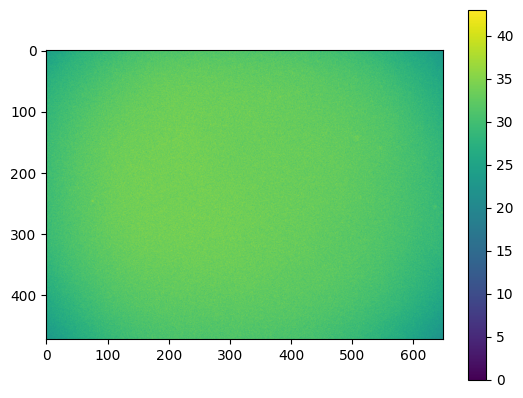

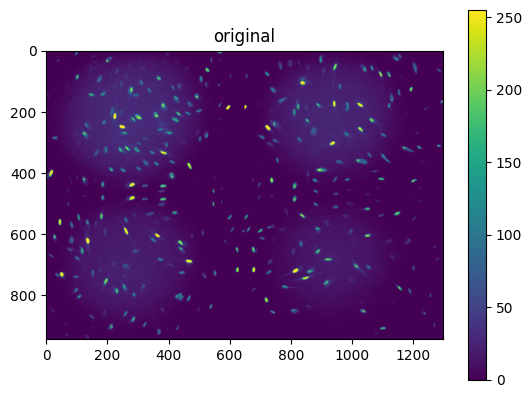

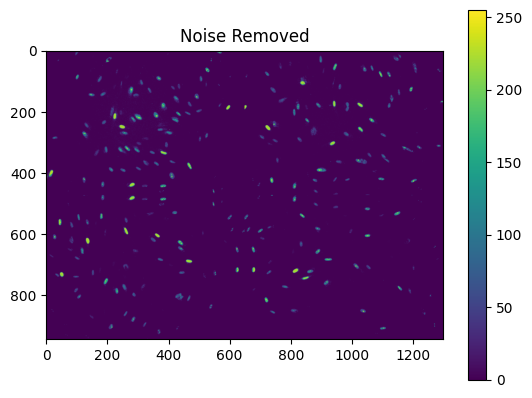

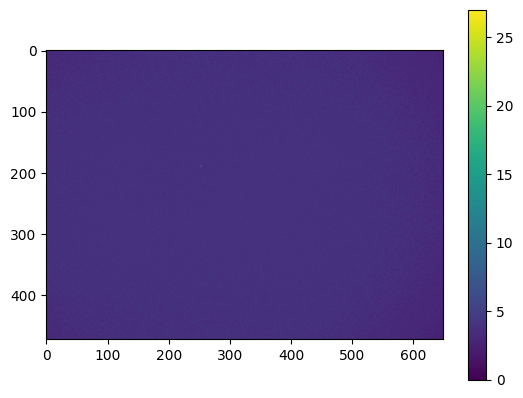

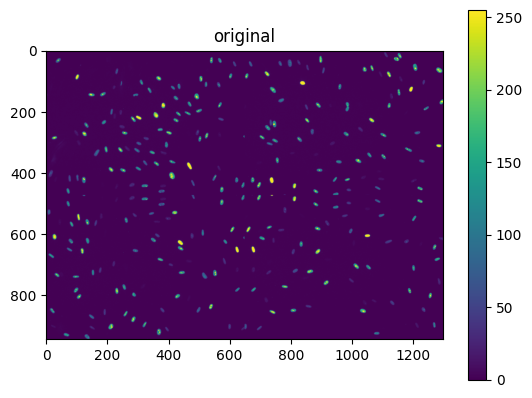

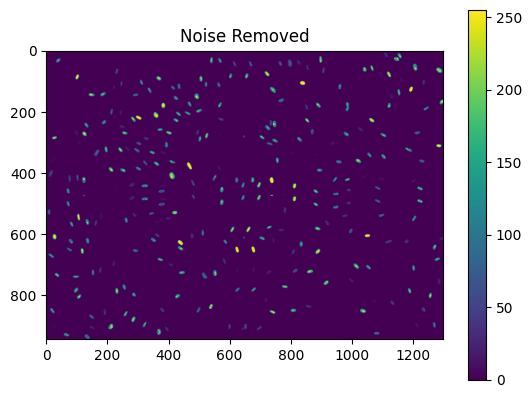

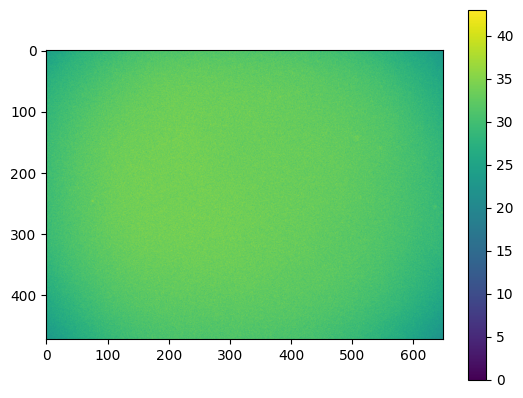

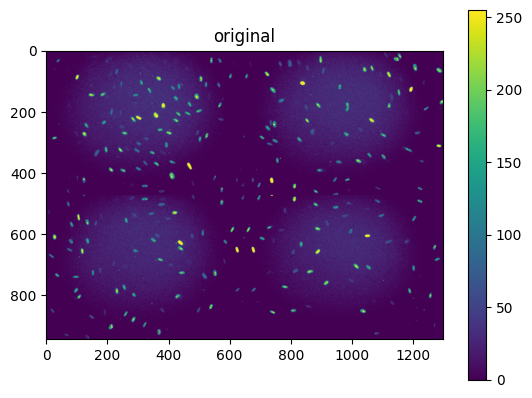

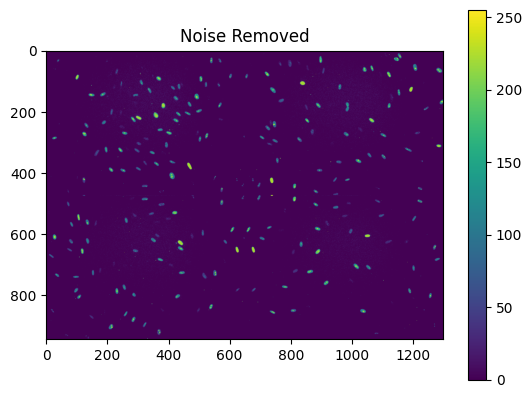

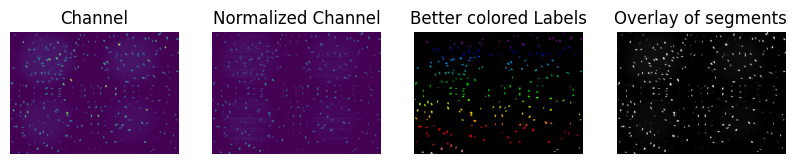

In [119]:

path = '/scratch/indikar_root/indikar1/shared_data/HYB/kaggle_dataset/datasets/thedoodler/hybrid-imaging-and-genex-dataset-hyb-imagen/versions/3'


run_experiment(path, 'Myod', 1, noisemap, 1, 3)

# run_experiment(path, 'Myod', 1)
#run_experiment('Myod', 2)
#run_experiment('PRRX1', 1)
#run_experiment('PRRX1', 2)
#run_experiment('Myod_PRRX1', 1)
#run_experiment('Myod_PRRX1', 2)
#run_experiment('Myod_PRRX1', 3)
#run_experiment('Negative_Controls', 1)
#run_experiment('Negative_Controls', 2)
#run_experiment('Negative_Controls', 3)

### Loading from raw czi file

In [87]:
czi_0_24_hours = '2024-12-21-PRRX1-MYOD-3-01.czi'
czi_24_72_hours = '2024-12-22-PRRX1-MYOD-3-02.czi'


base_pth = Path("/scratch/indikar_root/indikar1/shared_data/imaging_test/full_CZIs")



pth = base_pth / czi_0_24_hours

czi = CziFile(pth)

metadata = czi.meta

# Get the shape of the data, the coordinate pairs are (start index, size)
dimensions = czi.get_dims_shape()

my_dims = czi.dims

my_size = czi.size

is_mosaic = czi.is_mosaic()

x = dimensions[0]['X'][1]
y = dimensions[0]['Y'][1]
timepoints = dimensions[0]['T'][1] - 1

current_img = czi.read_mosaic(C=2, T=1, Z=0, scale_factor = 0.5)

proc_img = current_img[0, 0, 0, :, :]

# # print the full metadata tree
# for elem in metadata.iter():
#     # Print tag names and values
#     print(elem.tag, elem.text)  

print(proc_img.shape)
# fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(proc_img[:1000,:1000])

img, shp = czi.read_image(S=1, Z=0, T=1, M=1)

print('Is Mosaic file: ', czi.is_mosaic())
print(dimensions)
print(my_dims)
print(my_size)
print(shp)
print(img.shape)

timepoints = dimensions[0]['T'][1]


for i in range(4):
    img, shp = czi.read_image(S=1, Z=0, T=i*3, M=1)
    taggfp, mkate, cy5, oblique, taggfp_mkate, cur_rgb = plot_image(img)
    plot_image(img)


(10890, 25515)
Is Mosaic file:  True
[{'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 68), 'M': (0, 30), 'S': (0, 1), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (1, 2), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (2, 3), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (3, 4), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (4, 5), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (5, 6), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (6, 7), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 67), 'M': (0, 30), 'S': (7, 8), 'H': (0, 1)}, {'X': (0, 649), 'Y': (0, 471), 'Z': (0, 1), 'C': (0, 4), 'T': (0, 

IndexError: index 1 is out of bounds for axis 0 with size 1

# Tracking
### reloading saved tifffiles into memory for tracking

In [ ]:
# Reload tifffiles back
import matplotlib.pyplot as plt
import numpy as np
from skimage import io


# num_frames = 66
num_frames = 60
# num_frames = 30

original_cy5_imgs = [
    io.imread(f'mosaic_tiffs/original/{t}_cy5.tif')
    for t in range(1, num_frames)
]

original_mkate_imgs = [
    io.imread(f'mosaic_tiffs/original/{t}_mkate.tif')
    for t in range(1, num_frames)
]

cy5_segmentation_masks = [
    io.imread(f'mosaic_tiffs/segmentation/{t}_cy5.tif')
    for t in range(1, num_frames)
]

graphs = [
    io.imread(f'mosaic_graphs/{t}.png')
    for t in range(1, num_frames)
]

imagexshape, imageyshape = original_cy5_imgs[0].shape

# Convert to numpy arrays
original_imgs = np.stack(original_cy5_imgs)
# original_imgs = np.stack(original_mkate_imgs)
segmentation_masks = np.stack(cy5_segmentation_masks)

segmentation = segmentation_masks

# for i in range(num_frames):
#     img = original_cy5_imgs[i]
#     mask = cy5_segmentation_masks[i]
#     fig, ax = plt.subplots(figsize=(10, 10))
#     ax.imshow(img)

seq = montage(
    segmentation[::20, ::10, ::10], 
    grid_shape=(5, 5), 
    padding_width=10, 
    fill=255,
)

fig, ax = plt.subplots(1, figsize=(16, 16))
ax.imshow(seq, cmap=plt.cm.gray)
ax.axis(False)
plt.show()

In [ ]:
CONFIG_FILE = datasets.cell_config()
SEGMENTATION_FILE = datasets.example_segmentation_file()
OBJECTS_FILE = datasets.example_track_objects_file()

FEATURES = [
    "area", 
    "major_axis_length", 
    "minor_axis_length", 
    "orientation", 
    "solidity"
]

objects = btrack.utils.segmentation_to_objects(
    segmentation, 
    properties=tuple(FEATURES), 
    num_workers=4,  # parallelise this
)

### Perform Tracking

In [ ]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration
    
    # export the track data 
    # tracker.export("tracks.h5", obj_type="obj_type_1")
    

# Run Napari to visualize tracks and segments

In [ ]:

viewer = napari.Viewer()

viewer.add_image(
    segmentation, 
    name="Segmentation",
    opacity=0.3,
)

viewer.add_image(
    original_imgs, 
    name="Original Images",
    opacity=0.75,
)

# the track data from the tracker
viewer.add_tracks(
    data, 
    properties=properties, 
    graph=graph,
    name="Tracks", 
    blending="translucent",
    visible=True,
)


napari.run()